<a href="https://colab.research.google.com/github/alanperez0310-beep/Modelado-de-sistemas-El-ctricos-circuito-con-OPAMPs/blob/main/5%20Transformaci%C3%B3n%20de%20similitud/Pr%C3%A1ctica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [291]:
!wget -nc 'https://raw.githubusercontent.com/Jegovila/SSPIA1/main/5%20Transformación%20de%20similitud/ref_1.png'
!wget -nc 'https://raw.githubusercontent.com/Jegovila/SSPIA1/main/5%20Transformación%20de%20similitud/des.png'
!wget -nc 'https://raw.githubusercontent.com/Jegovila/SSPIA1/main/5%20Transformación%20de%20similitud/ref_3.png'

import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow
from IPython import display

File ‘ref_1.png’ already there; not retrieving.

File ‘des.png’ already there; not retrieving.

File ‘ref_3.png’ already there; not retrieving.



# Funciones

Transformación de similitud

In [292]:
def Transformacion_Similitud(q,x):
    dx = q[0]
    dy = q[1]
    theta = q[2]
    s = q[3]

    xp1 = [s*np.cos(theta)*x[0]-s*np.sin(theta)*x[1]+dx]
    xp2 = [s*np.sin(theta)*x[0]+s*np.cos(theta)*x[1]+dy]
    xp = np.array([xp1, xp2])
    return xp

Distancia Euclidiana

In [293]:
def Distancia_Euclidiana(xr, xp):
    e = np.sqrt((xr[0]-xp[0])**2 + (xr[1]-xp[1])**2)
    return e

Generar Resultado

In [294]:
def Generar_Resultado(q, img_dst, img_ref):
    dx = q[0]
    dy = q[1]
    theta = q[2]
    s = q[3]

    T = np.matrix([[s*np.cos(theta), -s*np.sin(theta), dx],
                   [s*np.sin(theta), s*np.cos(theta), dy],
                   [0, 0, 1]])
    Tp = T.T

    N, M, _ = img_ref.shape
    n, m, _ = img_dst.shape

    img_out= cv2.warpPerspective(img_dst, T, (M, N))

    # Para pegar una imagen sobre otra
    thresh = cv2.threshold(cv2.cvtColor(img_out, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY)[1]
    foreground = img_out.copy()
    background = img_ref.copy()
    alpha = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
    foreground = foreground.astype(float)
    background = background.astype(float)
    alpha = alpha.astype(float) / 255
    foreground = cv2.multiply(alpha, foreground)
    background = cv2.multiply(1 - alpha, background)
    outImage = cv2.add(foreground, background)
    outImage = outImage.astype(np.uint8)

    return outImage

# Algoritmo

Leer imágenes de entrada (qr y dst)

In [314]:
img_ref = cv2.imread('ref_1.png')
H, W, _ = img_ref.shape

img_dst = cv2.imread('des.png')
h, w, _ = img_dst.shape

Detectar QR

In [315]:
detect = cv2.QRCodeDetector()
_, points, _ = detect.detectAndDecode(img_ref)

xr0 = points[0, 0]
xr1 = points[0, 1]
xr2 = points[0, 2]
#xr3 = points[0, 3]

x0 = [0, 0]
x1 = [w, 0]
x2 = [w, h]

## Algoritmo de optimización

En esta parte ustedes elijan el algoritmo de optimización que gusten, dejo la plantilla de uno de estrategias evolutivas para que se den una idea de cómo debería verse: el primer bloque son los parámetros e inicialización, el segundo es el algoritmo.

Parámetros

In [316]:
# AQUI ELEGIR LA CONFIGURACIÓN ADECUADA
xl = np.array([0, 0, -np.pi, 0])
xu = np.array([W, H, np.pi, 10.0])


G =180
mu =18
l =126
D =4

x = np.zeros((D, mu))
sigma = np.zeros((D, mu))
fitness = np.zeros(mu)

p_plot = np.zeros(G)

Algoritmo

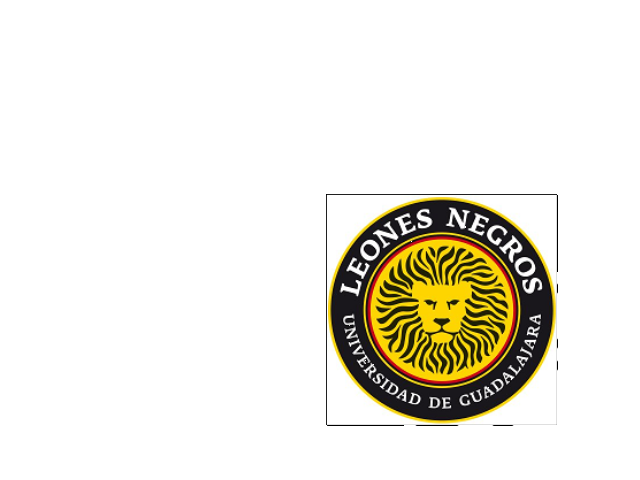

<Figure size 640x480 with 0 Axes>

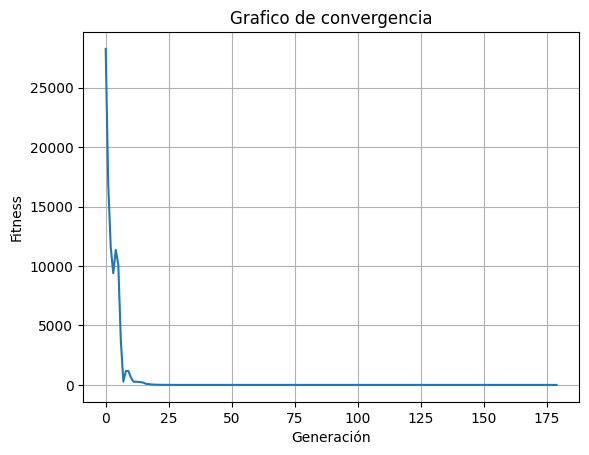

In [317]:

for i in range(mu):
    x[:, i] = xl + (xu - xl) * np.random.rand(D)

    sigma[:, i] = 0.12 * (xu - xl)

    q = x[:, i]

    # 1. Transformación
    xp0 = Transformacion_Similitud(q, x0)
    xp1 = Transformacion_Similitud(q, x1)
    xp2 = Transformacion_Similitud(q, x2)

    # 2. Errores
    e0 = Distancia_Euclidiana(xr0, xp0)
    e1 = Distancia_Euclidiana(xr1, xp1)
    e2 = Distancia_Euclidiana(xr2, xp2)

    # 3. Fitness
    fitness[i] = (e0**2 + e1**2 + e2**2) / 3


# Parametros auto-adaptación
tau  = 1 / np.sqrt(2*np.sqrt(D))
taup = 1 / np.sqrt(2*D)



for g in range(G):

    # Arreglos de hijos
    hijos_x = np.zeros((D, l))
    hijos_sigma = np.zeros((D, l))
    hijos_fit = np.zeros(l)

    for j in range(l):
        # Selección de padre
        p = np.random.randint(mu)

        # Autoadaptacion de sigma
        N0 = np.random.randn()
        Ni = np.random.randn(D)
        sigma_nueva = sigma[:, p] * np.exp(taup*N0 + tau*Ni)

        # Mutación
        x_nueva = x[:, p] + sigma_nueva * np.random.randn(D)
        x_nueva = np.clip(x_nueva, xl, xu)

        # Evaluación
        xp0 = Transformacion_Similitud(x_nueva, x0)
        xp1 = Transformacion_Similitud(x_nueva, x1)
        xp2 = Transformacion_Similitud(x_nueva, x2)

        e0 = Distancia_Euclidiana(xr0, xp0)
        e1 = Distancia_Euclidiana(xr1, xp1)
        e2 = Distancia_Euclidiana(xr2, xp2)

        fit = (e0**2 + e1**2 + e2**2) / 3

        hijos_x[:, j] = x_nueva
        hijos_sigma[:, j] = sigma_nueva
        hijos_fit[j] = fit

    x = hijos_x
    sigma = hijos_sigma
    fitness = hijos_fit

    Idx = np.argsort(fitness)
    x = x[:, Idx]
    sigma = sigma[:, Idx]
    fitness = fitness[Idx]

    p_plot[g] = np.min(fitness)

q = x[:, 0]

display.display(plt.gcf())
display.clear_output(wait=True)
img = Generar_Resultado(q, img_dst, img_ref)
cv2_imshow(img)

plt.figure()
plt.plot(p_plot)
plt.title("Grafico de convergencia")
plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.grid()
